# **FOOD DELIVERY SQL ANALYTICS PROJECT**

**Import Libraries**

In [17]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

**Connect SQLite Database**

In [18]:
conn = sqlite3.connect("food_delivery.db")

**Load Datasets**

In [19]:
meals = pd.read_csv(
    "https://assets.datacamp.com/production/repositories/4016/datasets/732c094b30a2e794d0b12b12547587a903126f68/meals.csv",
    header=None,
    names=["meal_id", "eatery", "meal_price", "meal_cost"]
)

orders = pd.read_csv(
    "https://assets.datacamp.com/production/repositories/4016/datasets/606e6e9165c25477db078996fa7e0a3e994b93d3/orders.csv",
    header=None,
    names=["order_date", "user_id", "order_id", "meal_id", "order_quantity"]
)

stock = pd.read_csv(
    "https://assets.datacamp.com/production/repositories/4016/datasets/10d9ad146a85010d836cfc93870aa464951f0640/stock.csv",
    header=None,
    names=["stocking_date", "meal_id", "stocked_quantity"]
)

**Create SQL Tables**

In [20]:
# Create tables
meals.to_sql("meals", conn, if_exists="replace", index=False)
orders.to_sql("orders", conn, if_exists="replace", index=False)
stock.to_sql("stock", conn, if_exists="replace", index=False)

print("Database ready")


Database ready


**Preview data**

In [22]:
print("Meals")
display(meals.head())

print("Orders")
display(orders.head())

print("Stock")
display(stock.head())

Meals


,meal_id,eatery,meal_price,meal_cost
0,0,'Leaning Tower of Pizza',4.0,2.00
1,1,'Leaning Tower of Pizza',3.5,1.25
2,2,'Leaning Tower of Pizza',4.5,1.75
3,3,'Leaning Tower of Pizza',4.0,0.75
4,4,'Burgatorio',6.0,3.25


Orders


,order_date,user_id,order_id,meal_id,order_quantity
0,2018-06-01,0,0,4,3
1,2018-06-01,0,0,14,2
2,2018-06-01,0,0,15,1
3,2018-06-01,0,0,17,1
4,2018-06-01,1,1,16,2


Stock


,stocking_date,meal_id,stocked_quantity
0,2018-06-01,0,76
1,2018-06-01,1,42
2,2018-06-01,2,56
3,2018-06-01,3,74
4,2018-06-01,4,100


**1. Revenue for Customer ID 15**

In [26]:
query = """
SELECT
    SUM(meals.meal_price * orders.order_quantity) AS revenue
FROM meals
JOIN orders
ON meals.meal_id = orders.meal_id
WHERE orders.user_id = 15
"""

revenue_customer = pd.read_sql(query, conn)

print("Revenue for Customer 15")
display(revenue_customer)

Revenue for Customer 15


,revenue
0,271.0


**2. Weekly Revenue in June 2018**

,delivr_week,revenue
0,2018-05-27,416.25
1,2018-06-03,1460.50
2,2018-06-10,1636.75
3,2018-06-17,1600.25
4,2018-06-24,1182.50


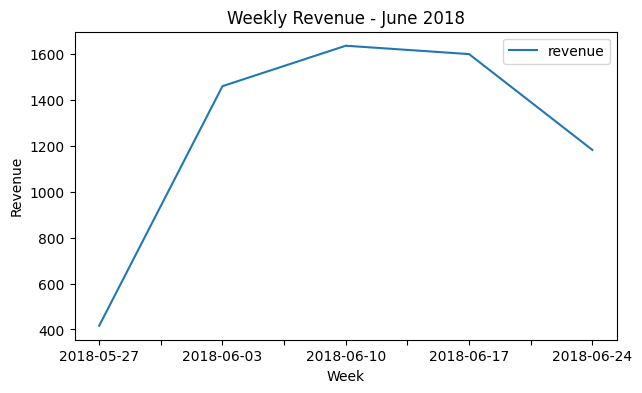

In [28]:
query = """
SELECT
    date(order_date, '-' || strftime('%w', order_date) || ' days') AS delivr_week,
    SUM(meals.meal_price * orders.order_quantity) AS revenue
FROM meals
JOIN orders ON meals.meal_id = orders.meal_id
WHERE substr(order_date, 1, 7) = '2018-06'
GROUP BY delivr_week
ORDER BY delivr_week ASC
"""

weekly_revenue = pd.read_sql(query, conn)

display(weekly_revenue)

weekly_revenue.plot(
    x='delivr_week',
    y='revenue',
    figsize=(7,4)
)

plt.title('Weekly Revenue - June 2018')
plt.xlabel('Week')
plt.ylabel('Revenue')

plt.show()

**3. Cost per meal ID, top 5 meal IDs by purchase cost**

,meal_id,cost
0,5,12248.00
1,4,10211.50
2,6,8219.75
3,13,6648.75
4,14,6030.00


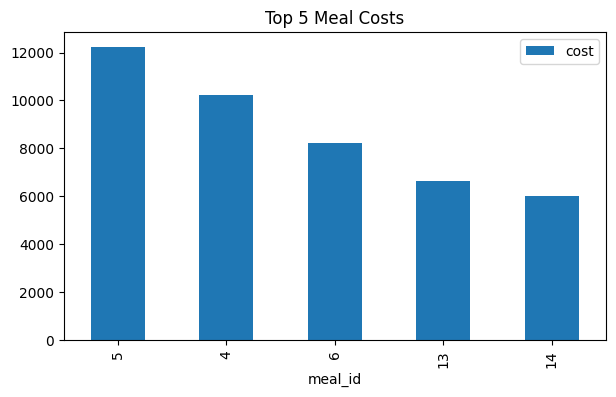

In [29]:
query = """
SELECT
    meals.meal_id,
    SUM(meals.meal_cost * stock.stocked_quantity) AS cost
FROM meals
JOIN stock ON meals.meal_id = stock.meal_id
GROUP BY meals.meal_id
ORDER BY cost DESC
LIMIT 5
"""

meal_cost = pd.read_sql(query, conn)

display(meal_cost)

meal_cost.plot.bar(
    x='meal_id',
    y='cost',
    figsize=(7,4)
)

plt.title('Top 5 Meal Costs')
plt.show()

**4. Average monthly cost before September 2018**

In [30]:
query = """
WITH monthly_cost AS (
    SELECT
        substr(stocking_date, 1, 7) AS delivr_month,
        SUM(meal_cost * stocked_quantity) AS cost
    FROM meals
    JOIN stock ON meals.meal_id = stock.meal_id
    GROUP BY delivr_month
)

SELECT AVG(cost) AS avg_cost
FROM monthly_cost
WHERE delivr_month < '2018-09'
"""

pd.read_sql(query, conn)

,avg_cost
0,3727.583333


**5. Profit per eatery**

,eatery,profit
0,'Bean Me Up Scotty',46854.50
1,'Burgatorio',37534.50
2,'The Moon Wok',36036.50
3,'Leaning Tower of Pizza',30692.50
4,'Life of Pie',16975.75


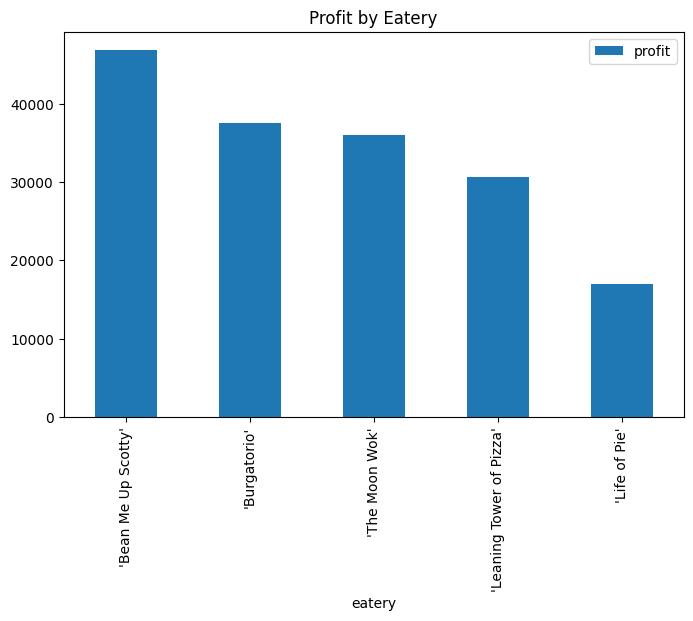

In [31]:
query = """
WITH revenue AS (
    SELECT
        meals.eatery,
        SUM(meals.meal_price * orders.order_quantity) AS revenue
    FROM meals
    JOIN orders ON meals.meal_id = orders.meal_id
    GROUP BY eatery
),

cost AS (
    SELECT
        meals.eatery,
        SUM(meals.meal_cost * stock.stocked_quantity) AS cost
    FROM meals
    JOIN stock ON meals.meal_id = stock.meal_id
    GROUP BY eatery
)

SELECT
    revenue.eatery,
    revenue.revenue - cost.cost AS profit
FROM revenue
JOIN cost ON revenue.eatery = cost.eatery
ORDER BY profit DESC
"""

profit = pd.read_sql(query, conn)

display(profit)

profit.plot.bar(
    x='eatery',
    y='profit',
    figsize=(8,5)
)

plt.title('Profit by Eatery')

plt.show()

**6. Profit per delivery month**

,delivr_month,profit
0,2018-06,4073.50
1,2018-07,6575.50
2,2018-08,9974.25
3,2018-09,15339.50
4,2018-10,23087.50
5,2018-11,38743.00
6,2018-12,70300.50


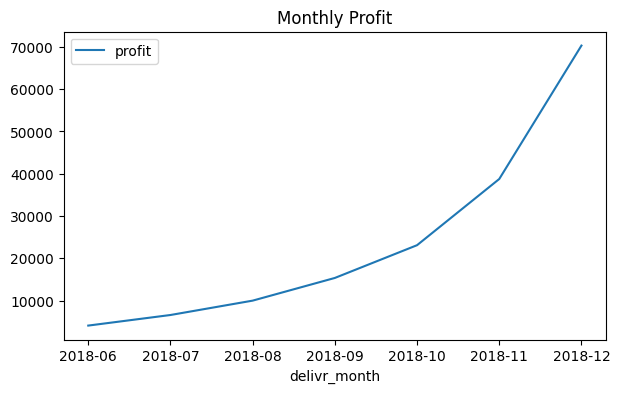

In [33]:
query = """
WITH revenue AS (
    SELECT
        substr(order_date, 1, 7) AS delivr_month,
        SUM(meals.meal_price * orders.order_quantity) AS revenue
    FROM meals
    JOIN orders ON meals.meal_id = orders.meal_id
    GROUP BY delivr_month
),

cost AS (
    SELECT
        substr(stocking_date, 1, 7) AS delivr_month,
        SUM(meals.meal_cost * stock.stocked_quantity) AS cost
    FROM meals
    JOIN stock ON meals.meal_id = stock.meal_id
    GROUP BY delivr_month
)

SELECT
    revenue.delivr_month,
    revenue.revenue - cost.cost AS profit
FROM revenue
JOIN cost ON revenue.delivr_month = cost.delivr_month
ORDER BY revenue.delivr_month ASC
"""

monthly_profit = pd.read_sql(query, conn)

display(monthly_profit)

monthly_profit.plot(
    x='delivr_month',
    y='profit',
    figsize=(7,4)
)

plt.title('Monthly Profit')

plt.show()

**7. Registration count by month**

,delivr_month,regs
0,2018-06,123
1,2018-07,140
2,2018-08,157
3,2018-09,176
4,2018-10,199
5,2018-11,231
6,2018-12,278


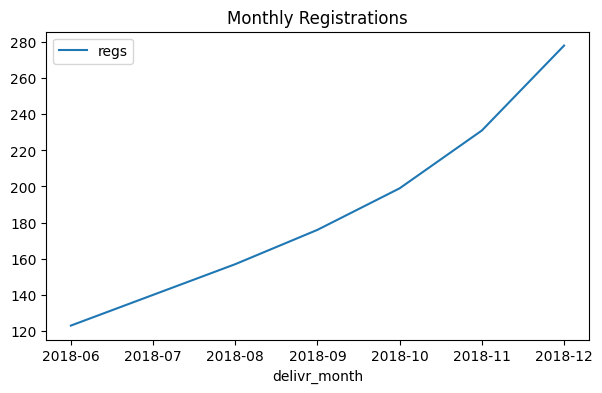

In [34]:
query = """
WITH reg_dates AS (
    SELECT
        user_id,
        MIN(order_date) AS reg_date
    FROM orders
    GROUP BY user_id
)

SELECT
    substr(reg_date, 1, 7) AS delivr_month,
    COUNT(DISTINCT user_id) AS regs
FROM reg_dates
GROUP BY delivr_month
ORDER BY delivr_month ASC
"""

regs = pd.read_sql(query, conn)

display(regs)

regs.plot(
    x='delivr_month',
    y='regs',
    figsize=(7,4)
)

plt.title('Monthly Registrations')

plt.show()

**8. Monthly Active Users (MAU)**

,delivr_month,mau
0,2018-06,123
1,2018-07,226
2,2018-08,337
3,2018-09,489
4,2018-10,689
5,2018-11,944
6,2018-12,1267


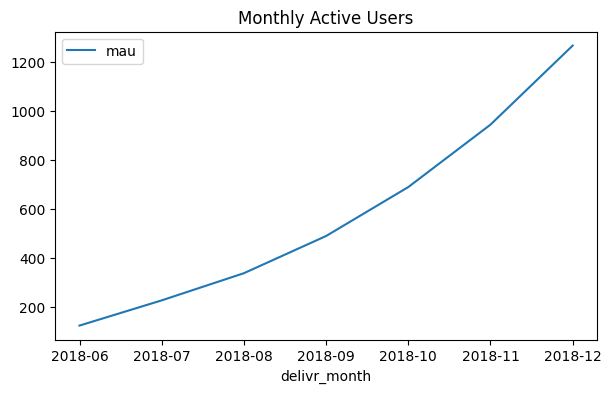

In [35]:
query = """
SELECT
    substr(order_date, 1, 7) AS delivr_month,
    COUNT(DISTINCT user_id) AS mau
FROM orders
GROUP BY delivr_month
ORDER BY delivr_month ASC
"""

mau = pd.read_sql(query, conn)

display(mau)

mau.plot(
    x='delivr_month',
    y='mau',
    figsize=(7,4)
)

plt.title('Monthly Active Users')

plt.show()

**9. Registration running total**

In [37]:
query = """
WITH reg_dates AS (
    SELECT
        user_id,
        MIN(order_date) AS reg_date
    FROM orders
    GROUP BY user_id
),

regs AS (
    SELECT
        substr(reg_date, 1, 7) AS delivr_month,
        COUNT(DISTINCT user_id) AS regs
    FROM reg_dates
    GROUP BY delivr_month
)

SELECT
    delivr_month,
    SUM(regs) OVER (ORDER BY delivr_month ASC) AS regs_rt
FROM regs
ORDER BY delivr_month ASC
"""

regs_rt = pd.read_sql(query, conn)

display(regs_rt)

,delivr_month,regs_rt
0,2018-06,123
1,2018-07,263
2,2018-08,420
3,2018-09,596
4,2018-10,795
5,2018-11,1026
6,2018-12,1304


**10. MAU delta**

In [38]:
query = """
WITH mau AS (
    SELECT
        substr(order_date, 1, 7) AS delivr_month,
        COUNT(DISTINCT user_id) AS mau
    FROM orders
    GROUP BY delivr_month
),

mau_with_lag AS (
    SELECT
        delivr_month,
        mau,
        COALESCE(
            LAG(mau) OVER (ORDER BY delivr_month ASC),
            0
        ) AS last_mau
    FROM mau
)

SELECT
    delivr_month,
    mau - last_mau AS mau_delta
FROM mau_with_lag
ORDER BY delivr_month ASC
"""

mau_delta = pd.read_sql(query, conn)

display(mau_delta)

,delivr_month,mau_delta
0,2018-06,123
1,2018-07,103
2,2018-08,111
3,2018-09,152
4,2018-10,200
5,2018-11,255
6,2018-12,323


**11. MoM (Month-over-Month) MAU growth rate**

,delivr_month,growth
0,2018-07,0.84
1,2018-08,0.49
2,2018-09,0.45
3,2018-10,0.41
4,2018-11,0.37
5,2018-12,0.34


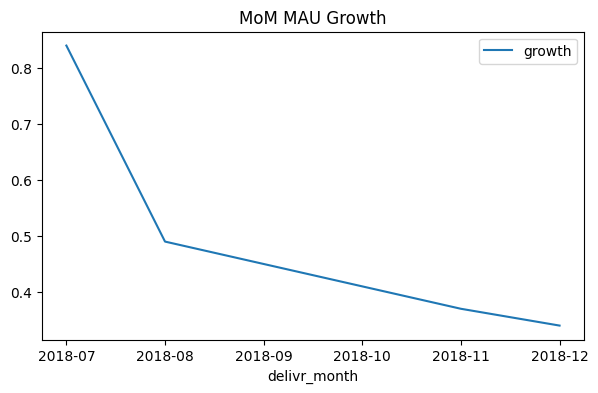

In [42]:
query = """
WITH mau AS (
    SELECT
        substr(order_date, 1, 7) AS delivr_month,
        COUNT(DISTINCT user_id) AS mau
    FROM orders
    GROUP BY delivr_month
),

mau_with_lag AS (
    SELECT
        delivr_month,
        mau,
        CASE
            WHEN LAG(mau) OVER (ORDER BY delivr_month ASC) IS NULL THEN 1
            ELSE LAG(mau) OVER (ORDER BY delivr_month ASC)
        END AS last_mau
    FROM mau
)

SELECT
    delivr_month,
    ROUND(
        CAST(mau - last_mau AS FLOAT) / last_mau,
        2
    ) AS growth
FROM mau_with_lag
WHERE delivr_month IS NOT "2018-06"
ORDER BY delivr_month ASC
"""

mau_growth = pd.read_sql(query, conn)

display(mau_growth)

mau_growth.plot(
    x='delivr_month',
    y='growth',
    figsize=(7,4)
)

plt.title('MoM MAU Growth')

plt.show()

**12. MoM order growth rate**

In [44]:
query = """
WITH monthly_orders AS (
    SELECT
        substr(order_date, 1, 7) AS delivr_month,
        COUNT(DISTINCT order_id) AS orders
    FROM orders
    GROUP BY delivr_month
),

orders_with_lag AS (
    SELECT
        delivr_month,
        orders,
        COALESCE(
            LAG(orders) OVER (ORDER BY delivr_month ASC),
            1
        ) AS last_orders
    FROM monthly_orders
)

SELECT
    delivr_month,
    ROUND(
        CAST(orders - last_orders AS FLOAT) / last_orders,
        2
    ) AS growth
FROM orders_with_lag
WHERE delivr_month IS NOT "2018-06"
ORDER BY delivr_month ASC
"""

order_growth = pd.read_sql(query, conn)

display(order_growth)

,delivr_month,growth
0,2018-07,0.58
1,2018-08,0.51
2,2018-09,0.50
3,2018-10,0.54
4,2018-11,0.67
5,2018-12,0.86


**13. Retention rate**

In [57]:
query = """
WITH user_monthly_activity AS (
    SELECT DISTINCT
        substr(order_date, 1, 7) AS delivr_month,
        user_id
    FROM orders
)

SELECT
    previous.delivr_month,

    ROUND(
        CAST(COUNT(DISTINCT current.user_id) AS FLOAT) /
        CASE
            WHEN COUNT(DISTINCT previous.user_id) = 0 THEN 1
            ELSE COUNT(DISTINCT previous.user_id)
        END,
        2
    ) AS retention_rate

FROM user_monthly_activity AS previous

LEFT JOIN user_monthly_activity AS current
ON previous.user_id = current.user_id

AND previous.delivr_month =
    strftime(
        '%Y-%m',
        date(current.delivr_month || '-01', '-1 month')
    )

GROUP BY previous.delivr_month

ORDER BY previous.delivr_month ASC

"""

retention = pd.read_sql(query, conn)
retention = retention.iloc[1:-1]

display(retention)

,delivr_month,retention_rate
1,2018-07,0.70
2,2018-08,0.76
3,2018-09,0.83
4,2018-10,0.90
5,2018-11,0.96


**14. Average Revenue Per User (ARPU)**

In [60]:
query = """
WITH kpi AS (
    SELECT
        user_id,
        SUM(m.meal_price * o.order_quantity) AS revenue
    FROM meals AS m
    JOIN orders AS o ON m.meal_id = o.meal_id
    GROUP BY user_id
)

SELECT ROUND(AVG(revenue), 2) AS arpu
FROM kpi
"""

pd.read_sql(query, conn)

,arpu
0,199.56


**15. Frequency table of orders by user**

,orders,users
0,1,7
1,2,42
2,3,65
3,4,88
4,5,123
5,6,112
6,7,130
7,8,107
8,9,110
9,10,128


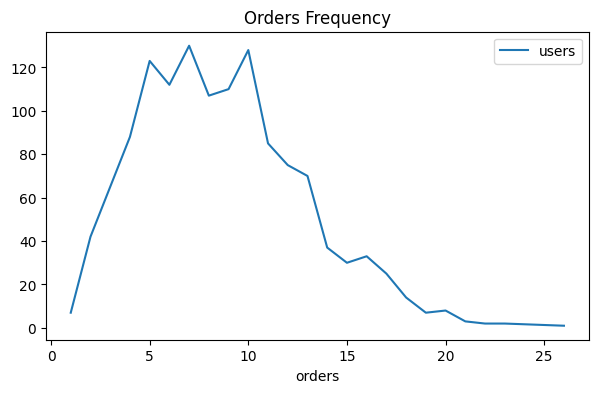

In [61]:
query = """
WITH user_orders AS (
    SELECT
        user_id,
        COUNT(DISTINCT order_id) AS orders
    FROM orders
    GROUP BY user_id
)

SELECT
    orders,
    COUNT(user_id) AS users
FROM user_orders
GROUP BY orders
ORDER BY orders ASC
"""

orders_frequency = pd.read_sql(query, conn)

display(orders_frequency)

orders_frequency.plot(
    x='orders',
    y='users',
    figsize=(7,4)
)

plt.title('Orders Frequency')

plt.show()

**16. Revenue segmentation**

,revenue_group,users
0,High-revenue users,225
1,Low-revenue users,473
2,Mid-revenue users,606


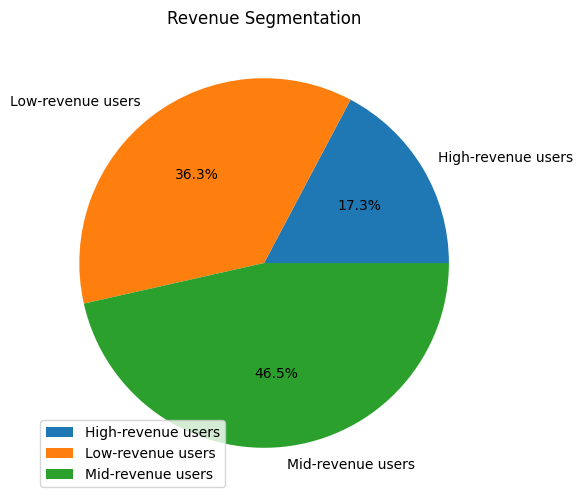

In [62]:
query = """
WITH user_revenues AS (
    SELECT
        o.user_id,
        SUM(m.meal_price * o.order_quantity) AS revenue
    FROM meals AS m
    JOIN orders AS o ON m.meal_id = o.meal_id
    GROUP BY user_id
)

SELECT
    CASE
        WHEN revenue < 150 THEN 'Low-revenue users'
        WHEN revenue >= 150 AND revenue < 300 THEN 'Mid-revenue users'
        ELSE 'High-revenue users'
    END AS revenue_group,
    COUNT(user_id) AS users
FROM user_revenues
GROUP BY revenue_group
"""

segments = pd.read_sql(query, conn)

display(segments)

segments.plot.pie(
    y='users',
    labels=segments['revenue_group'],
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Revenue Segmentation')

plt.ylabel('')

plt.show()

**17. Rank users by count_orders in August 2018**

In [69]:
query = """
WITH user_count_orders AS (
    SELECT
        user_id,
        COUNT(DISTINCT order_id) AS count_orders
    FROM orders
    WHERE substr(order_date, 1, 7) = '2018-08'
    GROUP BY user_id
)

SELECT
    user_id,
    count_orders,
    RANK() OVER (
        ORDER BY count_orders DESC
    ) AS count_orders_rank
FROM user_count_orders
ORDER BY count_orders_rank ASC
"""

user_rank = pd.read_sql(query, conn)

display(user_rank.head(5))


,user_id,count_orders,count_orders_rank
0,76,8,1
1,296,6,2
2,248,5,3
3,287,5,3
4,291,5,3


**18. Crosstab table of revenue by users/month**

In [70]:
query = """
SELECT
    user_id,
    SUM(
        CASE
            WHEN substr(order_date,1,7) = '2018-06'
            THEN meal_price * order_quantity
        END
    ) AS '2018-06-01',

    SUM(
        CASE
            WHEN substr(order_date,1,7) = '2018-07'
            THEN meal_price * order_quantity
        END
    ) AS '2018-07-01',

    SUM(
        CASE
            WHEN substr(order_date,1,7) = '2018-08'
            THEN meal_price * order_quantity
        END
    ) AS '2018-08-01'

FROM meals
JOIN orders
ON meals.meal_id = orders.meal_id

WHERE user_id IN (0,1,2,3,4)
AND order_date < '2018-09-01'

GROUP BY user_id
ORDER BY user_id
"""

crosstab_users = pd.read_sql(query, conn)

display(crosstab_users)

,user_id,2018-06-01,2018-07-01,2018-08-01
0,0,56.50,44.75,43.25
1,1,9.25,12.00,NaN
2,2,80.25,12.50,10.75
3,3,78.25,NaN,21.50
4,4,43.75,NaN,NaN


**19. Crosstab table of costs by eatery/month**

In [71]:
query = """
SELECT
    eatery,

    SUM(
        CASE
            WHEN substr(stocking_date,1,7) = '2018-11'
            THEN meal_cost * stocked_quantity
        END
    ) AS '2018-11-01',

    SUM(
        CASE
            WHEN substr(stocking_date,1,7) = '2018-12'
            THEN meal_cost * stocked_quantity
        END
    ) AS '2018-12-01'

FROM meals
JOIN stock
ON meals.meal_id = stock.meal_id

WHERE substr(stocking_date,1,7) > '2018-10'

GROUP BY eatery
ORDER BY eatery
"""

eatery_costs = pd.read_sql(query, conn)

display(eatery_costs)

,eatery,2018-11-01,2018-12-01
0,'Bean Me Up Scotty',3102.25,5810.50
1,'Burgatorio',7946.50,14197.75
2,'Leaning Tower of Pizza',3989.75,7256.00
3,'Life of Pie',523.50,946.50
4,'The Moon Wok',5825.00,10383.75


**20. Executive Report: ranking eatery by active users each quarter**

In [72]:
query = """
WITH eatery_users AS (
    SELECT
        eatery,

        CASE
            WHEN CAST(substr(order_date,6,2) AS INTEGER)
                BETWEEN 1 AND 3
            THEN 'Q1 2018'

            WHEN CAST(substr(order_date,6,2) AS INTEGER)
                BETWEEN 4 AND 6
            THEN 'Q2 2018'

            WHEN CAST(substr(order_date,6,2) AS INTEGER)
                BETWEEN 7 AND 9
            THEN 'Q3 2018'

            ELSE 'Q4 2018'
        END AS delivr_quarter,

        COUNT(DISTINCT user_id) AS users

    FROM meals
    JOIN orders
    ON meals.meal_id = orders.meal_id

    GROUP BY eatery, delivr_quarter
),

ranked AS (
    SELECT
        eatery,
        delivr_quarter,

        RANK() OVER (
            PARTITION BY delivr_quarter
            ORDER BY users DESC
        ) AS users_rank

    FROM eatery_users
)

SELECT
    eatery,

    MAX(
        CASE
            WHEN delivr_quarter = 'Q2 2018'
            THEN users_rank
        END
    ) AS 'Q2 2018',

    MAX(
        CASE
            WHEN delivr_quarter = 'Q3 2018'
            THEN users_rank
        END
    ) AS 'Q3 2018',

    MAX(
        CASE
            WHEN delivr_quarter = 'Q4 2018'
            THEN users_rank
        END
    ) AS 'Q4 2018'

FROM ranked

GROUP BY eatery

ORDER BY 'Q4 2018'
"""

executive_report = pd.read_sql(query, conn)

display(executive_report)

,eatery,Q2 2018,Q3 2018,Q4 2018
0,'Bean Me Up Scotty',2,2,3
1,'Burgatorio',2,2,2
2,'Leaning Tower of Pizza',4,4,4
3,'Life of Pie',5,5,5
4,'The Moon Wok',1,1,1
